In [ ]:
# Test data generated

In [ ]:
import pandas as pd
import numpy as np
import yaml
from a_data_generator.generator import DataGenerator
# from pathlib import Path
# import sys

# project_root = Path(__file__).resolve().parent.parent
# sys.path.append(str(project_root))

from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [13]:
print(project_root)

d:\fsds-ecommerce


In [9]:
df = pd.read_csv("../tests/a_data_generator/test_outputs/customers.csv")
print(df.head())

  customer_id                   signup_ts country segment  marketing_opt_in
0     C000001  2025-12-21 20:59:31.027760      VN  bronze              True
1     C000002  2026-04-24 02:55:05.027760      VN  bronze              True
2     C000003  2026-04-02 15:10:37.027760      VN  bronze              True
3     C000004  2026-02-22 19:22:58.027760      VN  silver              True
4     C000005  2026-02-21 18:03:13.027760      VN  bronze              True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       10 non-null     object
 1   signup_ts         10 non-null     object
 2   country           10 non-null     object
 3   segment           10 non-null     object
 4   marketing_opt_in  10 non-null     bool  
dtypes: bool(1), object(4)
memory usage: 462.0+ bytes


In [19]:
def validate_customers(customers, cfg):
    print("\n===== CUSTOMER VALIDATION =====")

    # Row count
    print(f"Expected customers: {cfg['n_customers']}")
    print(f"Actual customers:   {len(customers)}")

    # Country distribution
    print("\nCountry Distribution:")
    country_dist = customers["country"].value_counts(normalize=True)
    print(country_dist)

    # Segment distribution
    print("\nSegment Distribution:")
    segment_dist = customers["customer_segment"].value_counts(normalize=True)
    print(segment_dist)

    # Marketing opt-in rate
    print("\nMarketing Opt-in Rate:")
    opt_in_rate = customers["marketing_opt_in"].mean()
    print(f"{opt_in_rate:.2%}")

In [ ]:
generator = DataGenerator(
    config_path="D:\\fsds-ecommerce\\a_data_generator\\config.yaml"
)

customers = generator._generate_customers(
    generator.config
)

validate_customers(
    customers,
    generator.config
)



Config path loaded: D:\fsds-ecommerce\a_data_generator\config.yaml
[1/5] Generating 120,000 customers …


KeyError: 'skew_ratio_city'

In [ ]:
def build_distribution_dirichlet(cfg, skew_dict: dict, alpha:float = 2.0):
    '''Helper to build a distribution dict for a categorical variable with some skewness.'''
    rng = np.random.default_rng(cfg["random_seed"])
    fixed = {k: v for k, v in skew_dict.items() if isinstance(v, (int, float))}
    auto_keys = [k for k, v in skew_dict.items() if v == "auto"]
    
    fixed_sum = sum(fixed.values())
    remaining = 1.0 - fixed_sum
    
    if remaining < 0:
        raise ValueError(f"Fixed probabilities sum to {fixed_sum:.2f}, which exceeds 1.0")
    
    # If there are auto keys, we sample from a Dirichlet distribution to fill the remaining probability mass
    raw = rng.dirichlet(np.ones(len(auto_keys)) * alpha)
    
    final = dict(fixed)  # start with fixed values
    for k, r in zip(auto_keys, raw):
        final[k] = r * remaining
    
    # Normalize to ensure sum to 1 (handle any floating point issues)
    total = sum(final.values())
    for k in final:
        final[k] /= total
    return final

final = build_distribution_dirichlet(
    cfg=generator.config,
    skew_dict=generator.config["cities_distribution"],
    alpha=2.0
)
print("\nFinal City Distribution:")

for city, prob in final.items():
    print(f"{city}: {prob:.2%}")



Final City Distribution:
Ho Chi Minh City: 85.00%
Hanoi: 3.73%
Da Nang: 5.06%
Can Tho: 3.28%
Bien Hoa: 2.93%


# Validate

In [121]:
cus_df = pd.read_csv("../a_data_generator/outputs/customer_1000.csv")
prod_df = pd.read_csv("../a_data_generator/outputs/products_1000.csv")
order_df = pd.read_csv("../a_data_generator/outputs/orders_3000.csv")
order_items_df = pd.read_csv("../a_data_generator/outputs/order_items_7500.csv")
pay_df = pd.read_csv("../a_data_generator/outputs/payments_3000.csv")
cus_df.head()

,customer_id,signup_ts,country,segment,marketing_opt_in
0,C000001,2025-12-23 01:06:58.679207,VN,bronze,True
1,C000002,2026-04-25 07:02:32.679207,KR,bronze,True
2,C000003,2026-04-03 19:18:04.679207,VN,bronze,False
3,C000004,2026-02-23 23:30:25.679207,VN,bronze,False
4,C000005,2026-02-22 22:10:40.679207,VN,bronze,True


In [122]:
prod_df.head()

,product_id,category,brand,base_price,is_active,created_ts
0,P000001,electronics,Samsung,708.94,True,2026-01-26 19:04:36.679207
1,P000002,electronics,Sony,1734.43,True,2026-02-05 16:25:01.679207
2,P000003,electronics,Apple,353.80,True,2026-01-27 01:29:39.679207
3,P000004,home_living,Home Depot,971.97,True,2026-06-04 10:12:10.679207
4,P000005,electronics,LG,1877.25,True,2026-05-08 02:31:35.679207


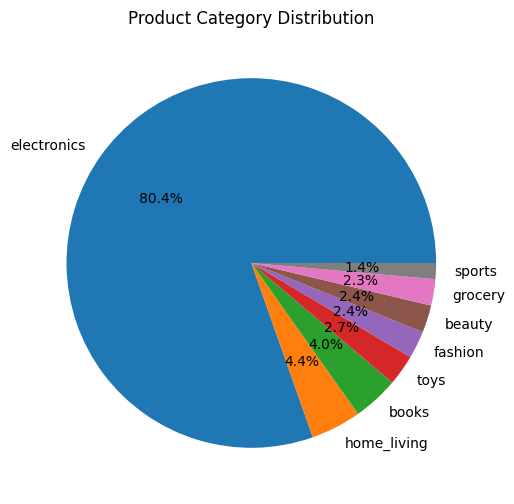

In [123]:
import matplotlib.pyplot as plt

category_dist = (
    prod_df["category"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6, 6))
plt.pie(
    category_dist,
    labels=category_dist.index,
    autopct="%1.1f%%"
)
plt.title("Product Category Distribution")
plt.show()

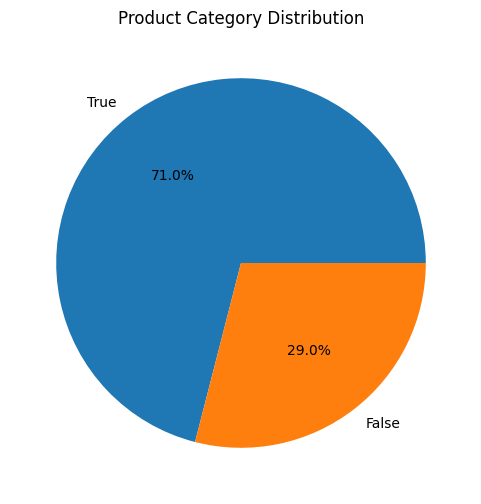

In [124]:
import matplotlib.pyplot as plt

category_dist = (
    cus_df["marketing_opt_in"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6, 6))
plt.pie(
    category_dist,
    labels=category_dist.index,
    autopct="%1.1f%%"
)
plt.title("Product Category Distribution")
plt.show()

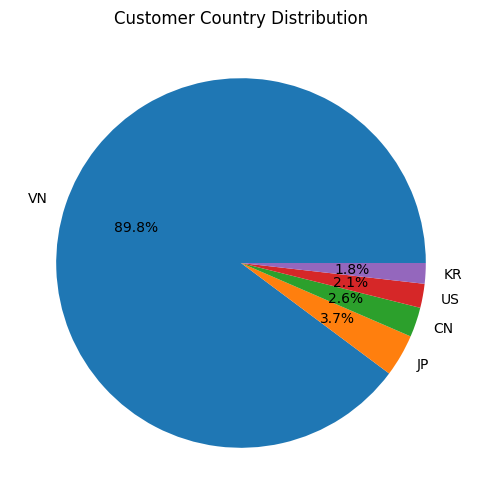

In [125]:
country_dist = (
    cus_df["country"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6, 6))
plt.pie(
    country_dist,
    labels=country_dist.index,
    autopct="%1.1f%%"
)
plt.title("Customer Country Distribution")
plt.show()

In [127]:
order_df.head()

,order_id,customer_id,order_timestamp,status,shipping_city,shipping_method,coupon_code
0,O000001,C000667,2026-03-24 14:43:47.679207,completed,Ho Chi Minh City,same_day,NaN
1,O000002,C000123,2026-05-04 21:58:34.679207,completed,Ho Chi Minh City,standard,SAVEUPTO20
2,O000003,C000820,2026-06-04 20:10:51.679207,completed,Da Nang,standard,NaN
3,O000004,C000259,2026-01-16 15:11:30.679207,completed,Bien Hoa,NaN,NaN
4,O000005,C000666,2026-05-16 07:23:51.679207,completed,Ho Chi Minh City,standard,NaN


In [128]:
print(
    order_items_df.duplicated(
        subset=[
            "order_id",
            "product_id",
            "quantity",
            "unit_price",
        ],
        keep=False,
    ).mean()
)

print(
    (order_df["order_timestamp"]
     < generator.config["schema_change_date"]).mean()
)

0.039477124183006536


TypeError: '<' not supported between instances of 'str' and 'datetime.datetime'

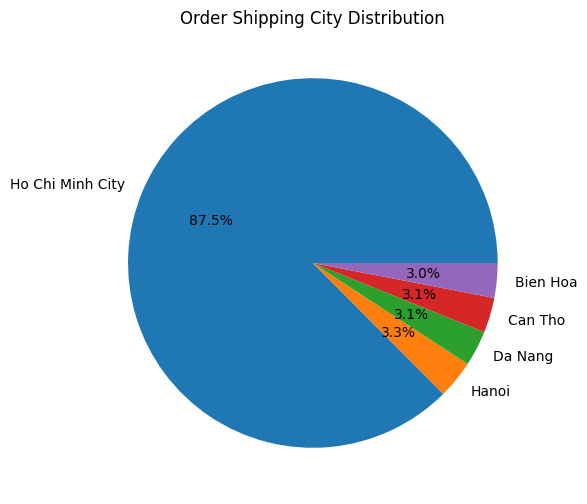

In [126]:
city_dist = (
    order_df["shipping_city"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6, 6))
plt.pie(
    city_dist,
    labels=city_dist.index,
    autopct="%1.1f%%"
)
plt.title("Order Shipping City Distribution")
plt.show()

In [ ]:
def _build_distribution_dirichlet(
    self, cfg, skew_dict: dict, alpha: float = 2.0
) -> dict:
    '''Helper to build a distribution dict for a categorical variable with skewness.'''
    rng = np.random.default_rng(cfg["random_seed"])

    fixed = {k: v for k, v in skew_dict.items() if isinstance(v, (int, float))}
    print(f"Fixed distribution: {fixed}")
    auto_keys = [k for k, v in skew_dict.items() if v == "auto"]
    print(f"Auto distribution keys: {auto_keys}")

    fixed_sum = sum(fixed.values())
    remaining = 1.0 - fixed_sum

    if remaining < 0:
        raise ValueError("Fixed probabilities exceed 1.0")

    raw = rng.dirichlet(np.ones(len(auto_keys)) * alpha)

    auto_dist = {k: w * remaining for k, w in zip(auto_keys, raw)}

    final = {**fixed, **auto_dist}
    print(f"Raw distribution: {final}")


    # normalize safety
    total = sum(final.values())
    final = {k: v / total for k, v in final.items()}
    print(f"Normalized distribution: {final}")
    return final

def _sample_from_distribution(self, rng, dist: dict, size: int):
    '''Helper to sample from a categorical distribution defined by dist dict.'''
    labels = list(dist.keys())
    probs = np.array(list(dist.values()))
    probs = probs / probs.sum()
    print(f"Sampling from distribution: {dist} with probs: {probs}")
    return rng.choice(labels, size=size, p=probs)

# Branch

In [68]:
def parse_brand_config(cfg: dict) -> None:
    """Parse and validate cfg["brands"] into two derived lookup dicts.

    Adds to cfg in-place:
        cfg["_brand_names"]   : {category: [name, ...]}
        cfg["_brand_weights"] : {category: np.ndarray of normalised weights}

    Raises:
        ValueError: on missing categories, duplicate names, non-positive
                    weights, or categories not in product_categories.
    """
    known_categories = set(cfg["product_categories"])
    seen_categories  = set()
    brand_names   = {}
    brand_weights = {}

    for i, entry in enumerate(cfg["brands"]):
        # ── required keys present ─────────────────────────────────────
        if "category" not in entry or "brands" not in entry:
            raise ValueError(
                f"brands[{i}] is missing 'category' or 'brands' key: {entry}"
            )

        cat    = entry["category"]
        brands = entry["brands"]

        # ── category is recognised ────────────────────────────────────
        if cat not in known_categories:
            raise ValueError(
                f"brands[{i}]: category '{cat}' not in product_categories: "
                f"{sorted(known_categories)}"
            )

        # ── no duplicate categories in the list ───────────────────────
        if cat in seen_categories:
            raise ValueError(f"brands[{i}]: category '{cat}' appears more than once")
        seen_categories.add(cat)

        # ── each brand entry has name + weight ────────────────────────
        for j, b in enumerate(brands):
            if "name" not in b or "weight" not in b:
                raise ValueError(
                    f"brands[{i}].brands[{j}] is missing 'name' or 'weight': {b}"
                )

        names   = [b["name"]   for b in brands]
        weights = [b["weight"] for b in brands]

        # ── no duplicate brand names within a category ─────────────────
        if len(names) != len(set(names)):
            dupes = [n for n in names if names.count(n) > 1]
            raise ValueError(
                f"brands[{i}] ('{cat}'): duplicate brand names: {sorted(set(dupes))}"
            )

        # ── all weights are positive numbers ──────────────────────────
        for name, w in zip(names, weights):
            if not isinstance(w, (int, float)) or w <= 0:
                raise ValueError(
                    f"brands[{i}] ('{cat}'): weight for '{name}' must be a "
                    f"positive number, got {w!r}"
                )

        arr = np.array(weights, dtype=float)
        brand_names[cat]   = names
        brand_weights[cat] = arr / arr.sum()   # normalise once, reuse everywhere

    # ── every product_category has a brands entry ─────────────────────
    missing = known_categories - seen_categories
    if missing:
        raise ValueError(
            f"No brands entry for product_categories: {sorted(missing)}"
        )

    cfg["_brand_names"]   = brand_names
    cfg["_brand_weights"] = brand_weights

In [ ]:
with open("D:\\fsds-ecommerce\\a_data_generator\\config.yaml") as f:
    cfg = yaml.safe_load(f)
parse_brand_config(cfg)
print("Parsed brand config successfully. Sample output:")
for cat in cfg["product_categories"]:
    print(
        f"{cat}: {cfg['_brand_names'][cat]} with weights {cfg['_brand_weights'][cat]}"
    )
rng = np.random.default_rng(cfg["random_seed"])
categories = cfg["product_categories"]
brands = [
    rng.choice(
        cfg["_brand_names"][cat],
        p=cfg["_brand_weights"][cat],
    )
    for cat in categories
]
print(f"Sampled brands for categories {categories}: {brands}")

Parsed brand config successfully. Sample output:
electronics: ['Samsung', 'Apple', 'Sony', 'LG', 'Dell'] with weights [0.3  0.25 0.2  0.15 0.1 ]
fashion: ['Zara', 'H&M', 'Uniqlo', 'Nike', 'Adidas'] with weights [0.25 0.25 0.2  0.15 0.15]
home_living: ['IKEA', 'Home Depot', "Lowe's", 'Wayfair', 'Bed Bath & Beyond'] with weights [0.2  0.25 0.25 0.15 0.15]
beauty: ["L'Oreal", 'Maybelline', 'Nivea', 'Dove', 'Clinique'] with weights [0.3  0.25 0.2  0.15 0.1 ]
sports: ['Nike', 'Adidas', 'Under Armour', 'Puma', 'Reebok'] with weights [0.25 0.25 0.2  0.15 0.15]
books: ['Penguin', 'HarperCollins', 'Simon & Schuster', 'Hachette', 'Macmillan'] with weights [0.3  0.25 0.2  0.15 0.1 ]
grocery: ['Walmart', 'Kroger', 'Costco', 'Whole Foods', 'Aldi'] with weights [0.25 0.25 0.2  0.15 0.15]
toys: ['LEGO', 'Hasbro', 'Mattel', 'Fisher-Price', 'Nerf'] with weights [0.3  0.25 0.2  0.15 0.1 ]
Sampled brands for categories ['electronics', 'fashion', 'home_living', 'beauty', 'sports', 'books', 'grocery', 'toy

# Data Visualisation

Explores the generated data across all five offline tables and the streaming events file.  
Sections map to the injected data problems documented in `01_data_generator.md`.

| Section | What it shows |
|---|---|
| 1. Overview | Row counts per table |
| 2. Customers | Segment / country / opt-in distributions |
| 3. Products | Category skew + price ranges |
| 4. Problem A | Geographic shipping-city skew |
| 5. Problem B | Schema-evolution NULL pattern over time |
| 6. Problem C | Duplicate injection in order_items |
| 7. Orders & Payments | Status and method distributions |
| 8. Problem D | Burst-traffic timeline (events/min) |
| 9. Problems E & F | Late arrivals + duplicate stream events |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
    }
)

OFFLINE = Path("../a_data_generator/outputs/offline")
STREAM = Path("../a_data_generator/outputs/streaming/events.json")

customers = pd.read_parquet(OFFLINE / "customers.parquet")
products = pd.read_parquet(OFFLINE / "products.parquet")
orders = pd.read_parquet(OFFLINE / "orders.parquet")
order_items = pd.read_parquet(OFFLINE / "order_items.parquet")
payments = pd.read_parquet(OFFLINE / "payments.parquet")

orders["order_timestamp"] = pd.to_datetime(orders["order_timestamp"])

print("Loaded tables:")
for name, df in [
    ("customers", customers),
    ("products", products),
    ("orders", orders),
    ("order_items", order_items),
    ("payments", payments),
]:
    print(f"  {name:<15}: {len(df):>8,} rows  |  {df.shape[1]} cols")

## 1. Data Overview

In [ ]:
table_names  = ["customers", "products", "orders", "order_items", "payments"]
table_frames = [customers, products, orders, order_items, payments]
row_counts   = [len(df) for df in table_frames]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(table_names, row_counts, color="#4C72B0", height=0.5)
ax.bar_label(bars, labels=[f"{n:,}" for n in row_counts], padding=6, fontsize=10)
ax.set_xlabel("Row count")
ax.set_title("Row Counts per Table")
ax.set_xlim(0, max(row_counts) * 1.18)
plt.tight_layout()
plt.show()

## 2. Customer Analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Segment distribution ────────────────────────────────────────────────────
seg = customers["segment"].value_counts()
colors_seg = {"bronze": "#CD7F32", "silver": "#C0C0C0", "gold": "#FFD700"}
axes[0].bar(
    seg.index, seg.values, color=[colors_seg.get(s, "#4C72B0") for s in seg.index]
)
for i, (label, val) in enumerate(zip(seg.index, seg.values)):
    axes[0].text(i, val + 5, f"{val/len(customers):.0%}", ha="center", fontsize=9)
axes[0].set_title("Customer Segments\n(target: 60% bronze · 30% silver · 10% gold)")
axes[0].set_ylabel("Count")

# ── Country distribution ────────────────────────────────────────────────────
country = customers["country"].value_counts()
axes[1].bar(country.index, country.values, color="#55A868")
for i, (label, val) in enumerate(zip(country.index, country.values)):
    axes[1].text(i, val + 3, f"{val/len(customers):.0%}", ha="center", fontsize=9)
axes[1].set_title("Customer Country\n(target: 90% VN)")
axes[1].set_ylabel("Count")

# ── Marketing opt-in ───────────────────────────────────────────────────────
opt_in_counts = customers["marketing_opt_in"].value_counts()
labels = ["Opted In" if v else "Opted Out" for v in opt_in_counts.index]
axes[2].pie(
    opt_in_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
)
rate = customers["marketing_opt_in"].mean()
axes[2].set_title(f"Marketing Opt-in\n(actual {rate:.0%}, target 70%)")

plt.suptitle("Customer Table", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Product Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Category distribution ───────────────────────────────────────────────────
cat_counts = products["category"].value_counts()
electronics_pct = cat_counts.get("electronics", 0) / len(products)
bar_colors = ["#E84C3D" if c == "electronics" else "#AEC6CF" for c in cat_counts.index]
axes[0].bar(cat_counts.index, cat_counts.values, color=bar_colors)
axes[0].axhline(
    len(products) * 0.80,
    color="red",
    linestyle="--",
    linewidth=1,
    label="80% target (electronics)",
)
axes[0].set_xticklabels(cat_counts.index, rotation=35, ha="right")
axes[0].set_title(
    f"Product Category Distribution\n(electronics actual: {electronics_pct:.0%}, target 80%)"
)
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# ── Price range per category ────────────────────────────────────────────────
top_cats = cat_counts.head(5).index.tolist()
price_data = [
    products.loc[products["category"] == c, "base_price"].values for c in top_cats
]
bp = axes[1].boxplot(
    price_data,
    labels=top_cats,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
)
for patch, color in zip(
    bp["boxes"], ["#E84C3D", "#AEC6CF", "#AEC6CF", "#AEC6CF", "#AEC6CF"]
):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(top_cats, rotation=20, ha="right")
axes[1].set_title("Base Price Distribution (top-5 categories)")
axes[1].set_ylabel("Price (USD)")

plt.suptitle("Product Table", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Problem A — Geographic Skew

**Target:** 85% of `orders.shipping_city` = Ho Chi Minh City.  
Downstream impact: Spark Gold jobs must handle partition skew; the Gold table is partitioned by `shipping_city`.

In [ ]:
city_counts = orders["shipping_city"].value_counts()
city_pcts = city_counts / len(orders)
hcmc_pct = city_pcts.get("Ho Chi Minh City", 0)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [
    "#E84C3D" if c == "Ho Chi Minh City" else "#AEC6CF" for c in city_counts.index
]
bars = ax.bar(city_counts.index, city_pcts.values * 100, color=bar_colors)
ax.axhline(85, color="red", linestyle="--", linewidth=1.2, label="85% target")
ax.bar_label(
    bars, labels=[f"{v:.1f}%" for v in city_pcts.values * 100], padding=3, fontsize=9
)
ax.set_ylabel("Share of orders (%)")
ax.set_title(
    f"Problem A — Shipping City Distribution  (HCMC: {hcmc_pct:.1%}, target 85%)"
)
ax.legend()
red_patch = mpatches.Patch(color="#E84C3D", label="Ho Chi Minh City")
blue_patch = mpatches.Patch(color="#AEC6CF", label="Other cities")
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
plt.tight_layout()
plt.show()

print(f"HCMC share : {hcmc_pct:.2%}  (target ≥ 85%)")

## 5. Problem B — Schema Evolution

**Target:** `coupon_code` and `shipping_method` are 100% NULL for orders before `schema_change_date`.  
Silver fills NULL → `'LEGACY'` / `'UNKNOWN'`.

In [ ]:
SCHEMA_CHANGE = pd.Timestamp("2026-03-24")

orders["order_date"] = pd.to_datetime(orders["order_timestamp"]).dt.normalize()
orders["period"]     = orders["order_timestamp"].apply(
    lambda t: "pre-change" if t < SCHEMA_CHANGE else "post-change"
)

# Weekly NULL rate over time
orders["week"] = orders["order_timestamp"].dt.to_period("W").dt.start_time
weekly = (
    orders.groupby("week")
    .agg(
        coupon_null=("coupon_code",    lambda s: s.isna().mean()),
        shipping_null=("shipping_method", lambda s: s.isna().mean()),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly["week"], weekly["coupon_null"] * 100,    label="coupon_code NULL %",    color="#4C72B0")
ax.plot(weekly["week"], weekly["shipping_null"] * 100,  label="shipping_method NULL %", color="#DD8452", linestyle="--")
ax.axvline(SCHEMA_CHANGE, color="red", linewidth=1.5, linestyle=":", label=f"schema_change_date ({SCHEMA_CHANGE.date()})")
ax.fill_betweenx([0, 110], ax.get_xlim()[0], SCHEMA_CHANGE,
                 alpha=0.06, color="red", label="old schema zone")
ax.set_ylim(0, 110)
ax.set_ylabel("NULL rate (%)")
ax.set_xlabel("Week")
ax.set_title("Problem B — NULL Rate Over Time for coupon_code & shipping_method")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pre  = orders[orders["period"] == "pre-change"]
post = orders[orders["period"] == "post-change"]
print(f"Pre-change orders : {len(pre):,}  → coupon NULL {pre['coupon_code'].isna().mean():.0%}  | shipping NULL {pre['shipping_method'].isna().mean():.0%}")
print(f"Post-change orders: {len(post):,}  → coupon NULL {post['coupon_code'].isna().mean():.0%}  | shipping NULL {post['shipping_method'].isna().mean():.0%}")

## 6. Problem C — Duplicate Order Items

**Target:** 2% of `order_items` rows duplicated on `(order_id, product_id, quantity, unit_price)`.  
Silver deduplicates, keeping the earliest `created_ts`.

In [ ]:
DUP_KEY = ["order_id", "product_id", "quantity", "unit_price"]

total_rows  = len(order_items)
dup_mask    = order_items.duplicated(subset=DUP_KEY, keep="first")
dup_rows    = dup_mask.sum()
clean_rows  = total_rows - dup_rows
dup_rate    = dup_rows / total_rows

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Bar: raw vs after dedup ─────────────────────────────────────────────────
axes[0].bar(["Raw (with dups)", "After dedup"], [total_rows, clean_rows],
            color=["#DD8452", "#55A868"], width=0.4)
axes[0].set_ylabel("Row count")
axes[0].set_title("Problem C — order_items Before vs After Dedup")
for i, v in enumerate([total_rows, clean_rows]):
    axes[0].text(i, v + total_rows * 0.005, f"{v:,}", ha="center", fontsize=10)

# ── Pie: dup vs unique ──────────────────────────────────────────────────────
axes[1].pie(
    [clean_rows, dup_rows],
    labels=["Unique rows", "Injected duplicates"],
    autopct="%1.2f%%",
    colors=["#55A868", "#DD8452"],
    startangle=90,
    explode=(0, 0.07),
)
axes[1].set_title(f"Duplicate share: {dup_rate:.2%}  (target 2%)")

plt.suptitle("Problem C — Duplicate Injection", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Total rows   : {total_rows:,}")
print(f"Duplicate rows : {dup_rows:,}  ({dup_rate:.2%} of total, target 2%)")
print(f"After dedup  : {clean_rows:,}")

## 7. Orders & Payments

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Order status ───────────────────────────────────────────────────────────
status_counts = orders["status"].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color="#4C72B0")
axes[0].set_xticklabels(status_counts.index, rotation=20, ha="right")
axes[0].set_title("Order Status Distribution")
axes[0].set_ylabel("Count")

# ── Payment method ─────────────────────────────────────────────────────────
method_counts = payments["payment_method"].value_counts()
axes[1].bar(method_counts.index, method_counts.values, color="#55A868")
axes[1].set_xticklabels(method_counts.index, rotation=20, ha="right")
axes[1].set_title("Payment Method\n(target: 40% credit_card, 25% bank_transfer, 25% e-wallet, 10% COD)")
axes[1].set_ylabel("Count")

# ── Payment status ─────────────────────────────────────────────────────────
pay_status = payments["payment_status"].value_counts()
fail_rate  = pay_status.get("failed", 0) / len(payments)
axes[2].pie(
    pay_status.values,
    labels=pay_status.index,
    autopct="%1.1f%%",
    colors=["#55A868", "#E84C3D", "#F0A500"],
    startangle=90,
)
axes[2].set_title(f"Payment Status\n(failure rate: {fail_rate:.1%}, target ~10%)")

plt.suptitle("Orders & Payments Tables", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Streaming Events — Problem D: Burst Traffic

**Target:** 30× rate spike during 12:00–12:20 and 20:00–20:20.  
Base rate: 100 events/min → burst peak: ~3,000 events/min.

In [ ]:
print("Loading streaming events (this may take a few seconds)…")
with open(STREAM) as f:
    events = [json.loads(line) for line in f]
events_df = pd.DataFrame(events)
events_df["event_timestamp"] = pd.to_datetime(events_df["event_timestamp"])
events_df["created_ts"]      = pd.to_datetime(events_df["created_ts"])
print(f"Loaded {len(events_df):,} events")

In [ ]:
events_df["minute"] = events_df["event_timestamp"].dt.floor("min")
per_minute = events_df.groupby("minute").size().reset_index(name="count")

# Burst windows (minutes of the day)
BURST_1_START = per_minute["minute"].iloc[0].normalize() + pd.Timedelta("12h")
BURST_1_END   = BURST_1_START + pd.Timedelta("20min")
BURST_2_START = per_minute["minute"].iloc[0].normalize() + pd.Timedelta("20h")
BURST_2_END   = BURST_2_START + pd.Timedelta("20min")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(per_minute["minute"], per_minute["count"], linewidth=0.8, color="#4C72B0", label="Events/min")
ax.axhline(100,  color="green",  linewidth=1, linestyle="--", label="Base rate (100/min)")
ax.axhline(3000, color="red",    linewidth=1, linestyle=":",  label="Peak target (3 000/min)")
ax.axvspan(BURST_1_START, BURST_1_END, alpha=0.15, color="red", label="Burst windows")
ax.axvspan(BURST_2_START, BURST_2_END, alpha=0.15, color="red")
peak = per_minute["count"].max()
ax.set_ylabel("Events per minute")
ax.set_xlabel("Time")
ax.set_title(f"Problem D — Burst Traffic Timeline  (peak: {peak:,} events/min)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Median rate : {per_minute['count'].median():.0f} events/min")
print(f"Peak rate   : {peak:,} events/min  (target ~3 000)")

## 9. Problems E & F — Late Arrivals and Duplicate Events

**Problem E:** 12% of events have `created_ts` delayed 5–45 min after `event_timestamp`.  
**Problem F:** 1.5% of events are re-emitted with the same `event_id` and a 1–3 min shift in `created_ts`.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Problem E: late arrival delay histogram ────────────────────────────────
originals = events_df.drop_duplicates(subset=["event_id"], keep="first").copy()
originals["delay_min"] = (
    (originals["created_ts"] - originals["event_timestamp"])
    .dt.total_seconds() / 60
)
late_mask  = originals["delay_min"] >= 5
late_rate  = late_mask.mean()
late_delays = originals.loc[late_mask, "delay_min"]

axes[0].hist(late_delays, bins=40, color="#DD8452", edgecolor="white")
axes[0].axvline(5,  color="red",  linewidth=1.2, linestyle="--", label="Min delay (5 min)")
axes[0].axvline(45, color="red",  linewidth=1.2, linestyle=":",  label="Max delay (45 min)")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Event count")
axes[0].set_title(f"Problem E — Late Arrival Delay Distribution\n(late rate: {late_rate:.1%}, target 12%)")
axes[0].legend(fontsize=9)

# ── Problem F: duplicate events ────────────────────────────────────────────
dup_events  = events_df[events_df.duplicated(subset=["event_id"], keep=False)]
dup_event_ids = dup_events["event_id"].unique()
n_dup_events  = len(dup_event_ids)
n_total       = events_df["event_id"].nunique()
dup_rate_f    = n_dup_events / n_total

# Shift in created_ts between original and duplicate
shifts = (
    dup_events.groupby("event_id")["created_ts"]
    .apply(lambda s: (s.max() - s.min()).total_seconds() / 60)
    .values
)
axes[1].hist(shifts, bins=30, color="#4C72B0", edgecolor="white")
axes[1].axvline(1, color="red", linewidth=1.2, linestyle="--", label="Min shift (1 min)")
axes[1].axvline(3, color="red", linewidth=1.2, linestyle=":",  label="Max shift (3 min)")
axes[1].set_xlabel("created_ts shift between original and duplicate (minutes)")
axes[1].set_ylabel("Duplicate event_id count")
axes[1].set_title(f"Problem F — Duplicate Event Timestamp Shift\n(dup rate: {dup_rate_f:.2%}, target 1.5%)")
axes[1].legend(fontsize=9)

plt.suptitle("Streaming Problems E & F", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Late arrivals : {late_mask.sum():,} events ({late_rate:.1%}, target 12%)")
print(f"Dup event_ids : {n_dup_events:,} unique event_ids duplicated ({dup_rate_f:.2%} of total, target 1.5%)")

## 10. Streaming Event Type Distribution

In [ ]:
event_type_counts = events_df["event_type"].value_counts()

TARGET = {
    "view": 0.50,
    "add_to_cart": 0.20,
    "checkout": 0.12,
    "purchase": 0.10,
    "payment_failed": 0.08,
}

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(event_type_counts))
actual_pcts  = event_type_counts.values / len(events_df) * 100
target_pcts  = [TARGET.get(et, 0) * 100 for et in event_type_counts.index]

width = 0.35
ax.bar([i - width/2 for i in x], actual_pcts,  width, label="Actual",  color="#4C72B0")
ax.bar([i + width/2 for i in x], target_pcts,  width, label="Target",  color="#AEC6CF", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(event_type_counts.index)
ax.set_ylabel("Share (%)")
ax.set_title("Streaming Event Type Distribution — Actual vs Target")
ax.legend()
for i, (a, t) in enumerate(zip(actual_pcts, target_pcts)):
    ax.text(i - width/2, a + 0.3, f"{a:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("\nEvent type summary:")
for et, cnt in event_type_counts.items():
    pct = cnt / len(events_df)
    target = TARGET.get(et, 0)
    ok = "✓" if abs(pct - target) < 0.02 else "!"
    print(f"  {ok} {et:<20}: {cnt:>8,}  ({pct:.1%} actual, {target:.0%} target)")